In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [5]:
data_path=Path('data/dataset_clean.csv')
df=pd.read_csv(data_path)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          89740 non-null  str    
 1   artists           89740 non-null  str    
 2   album_name        89740 non-null  str    
 3   track_name        89740 non-null  str    
 4   popularity        89740 non-null  int64  
 5   duration_ms       89740 non-null  int64  
 6   explicit          89740 non-null  bool   
 7   danceability      89740 non-null  float64
 8   energy            89740 non-null  float64
 9   key               89740 non-null  int64  
 10  loudness          89740 non-null  float64
 11  mode              89740 non-null  int64  
 12  speechiness       89740 non-null  float64
 13  acousticness      89740 non-null  float64
 14  instrumentalness  89740 non-null  float64
 15  liveness          89740 non-null  float64
 16  valence           89740 non-null  float64
 17  temp

In [7]:
df.shape

(89740, 20)

In [8]:
df.select_dtypes(include='number')

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,55,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89735,21,384999,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
89736,22,385000,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
89737,22,271466,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
89738,41,283893,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [9]:
features_for_clustering = ['danceability', 'energy', 'acousticness', 'instrumentalness','liveness', 'valence', 'speechiness','tempo' ]

In [10]:
X=df[features_for_clustering]

In [11]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

## Elbow method

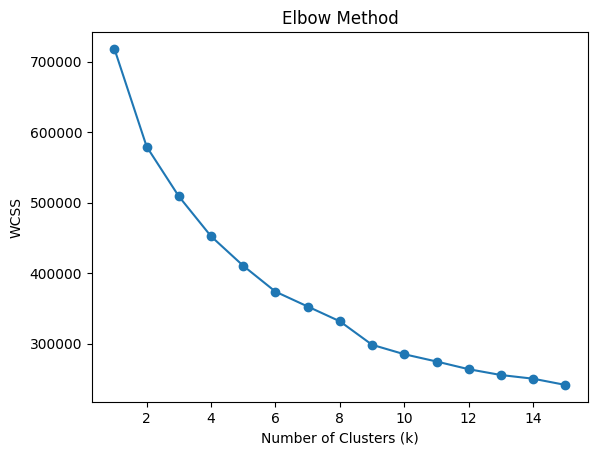

In [12]:
wcss=[]
for k in range (1,16):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 16), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [36]:
silhouette_scores = []
k_values = range(2, 11)
for k in k_values:
    # Modell inicializálása
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # Illesztés és a címkék (cluster_labels) generálása egy lépésben
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Silhouette score kiszámítása az adott K-ra
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

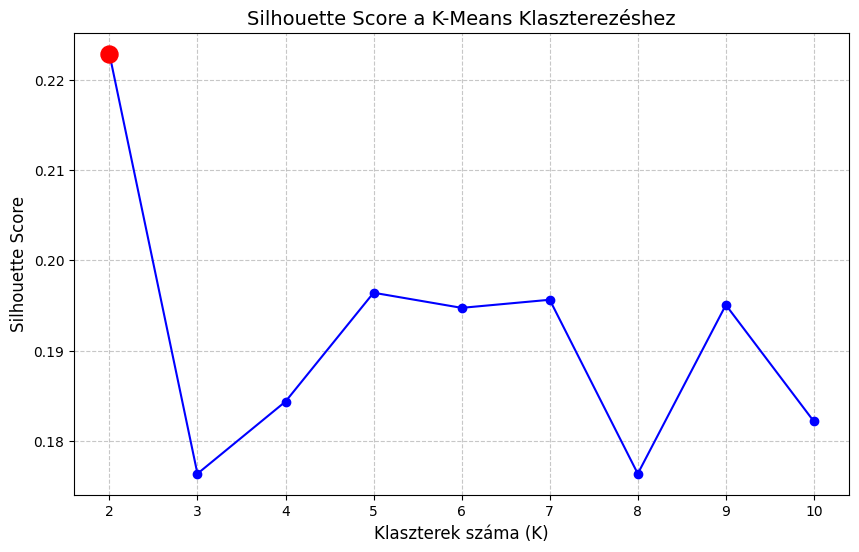

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='b')

# Dizájn elemek, hogy profin nézzen ki
plt.title('Silhouette Score a K-Means Klaszterezéshez', fontsize=14)
plt.xlabel('Klaszterek száma (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)

# Legmagasabb érték kiemelése pirossal (opcionális, de nagyon látványos)
optimal_k_index = silhouette_scores.index(max(silhouette_scores))
plt.scatter(k_values[optimal_k_index], max(silhouette_scores), color='red', s=150, zorder=5)

plt.show()

## Trying different K values

In [13]:
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(X_scaled)
df['cluster'] = cluster_labels
print(df['cluster'].value_counts())

cluster
0    35109
2    26185
1    20425
3     6962
4     1059
Name: count, dtype: int64


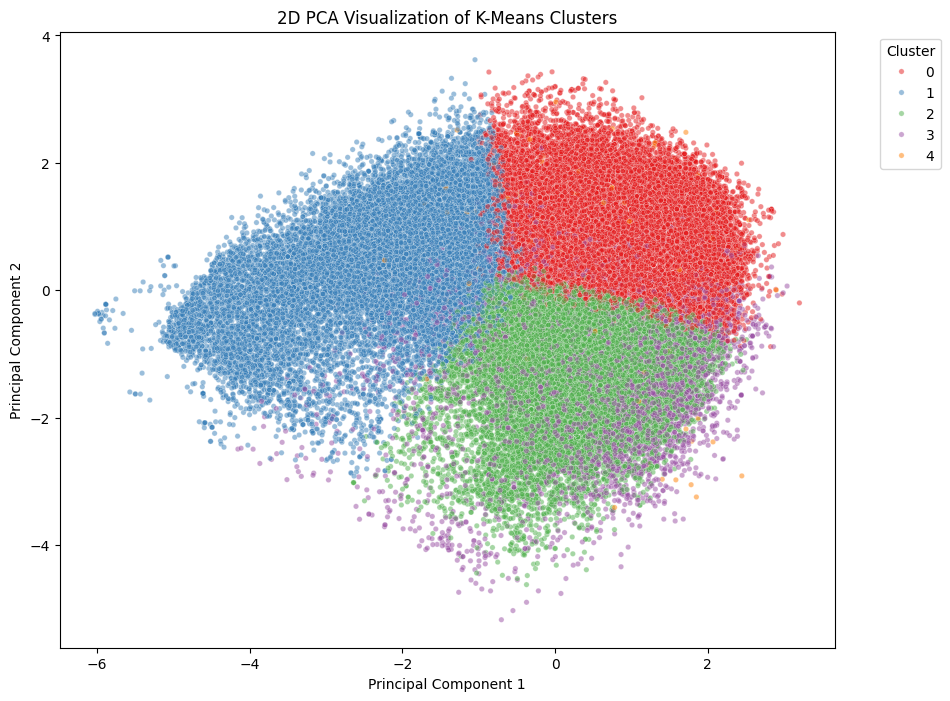

In [15]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='cluster', 
                palette='Set1', alpha=0.5, s=15)
plt.title('2D PCA Visualization of K-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [16]:
pca.explained_variance_ratio_

array([0.27752438, 0.17692962])

In [17]:
cluster_profiles=df.groupby('cluster')[features_for_clustering].mean()
print(cluster_profiles.round(3))

         danceability  energy  acousticness  instrumentalness  liveness  \
cluster                                                                   
0               0.691   0.691         0.256             0.055     0.163   
1               0.453   0.286         0.776             0.313     0.154   
2               0.487   0.799         0.069             0.249     0.185   
3               0.514   0.746         0.292             0.103     0.728   
4               0.570   0.677         0.739             0.009     0.663   

         valence  speechiness    tempo  
cluster                                 
0          0.682        0.092  119.502  
1          0.293        0.050  109.069  
2          0.317        0.080  136.028  
3          0.491        0.088  123.685  
4          0.440        0.841  101.199  


In [18]:
df['cluster'].value_counts()

cluster
0    35109
2    26185
1    20425
3     6962
4     1059
Name: count, dtype: int64

In [19]:
df[df['cluster'] == 4]['track_genre'].value_counts().head(20)

track_genre
comedy        804
show-tunes     31
kids           19
children       18
french         18
funk           16
iranian        10
disney          8
chill           7
jazz            7
dancehall       6
emo             6
sad             6
brazil          5
club            5
german          5
j-dance         5
classical       4
garage          4
grindcore       4
Name: count, dtype: int64

In [20]:

optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(X_scaled)
df['cluster'] = cluster_labels
print(df['cluster'].value_counts())

cluster
0    35584
2    26451
1    20563
3     7142
Name: count, dtype: int64


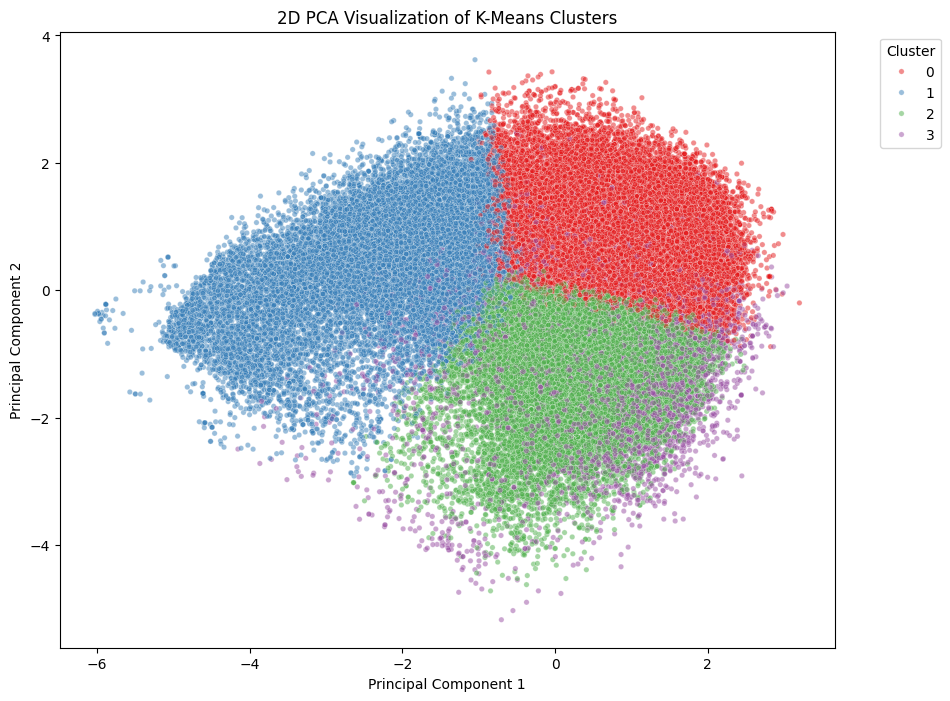

In [21]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='cluster', 
                palette='Set1', alpha=0.5, s=15)
plt.title('2D PCA Visualization of K-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [22]:
pca.explained_variance_ratio_

array([0.27752438, 0.17692962])

In [23]:
cluster_profiles=df.groupby('cluster')[features_for_clustering].mean()
print(cluster_profiles.round(3))

         danceability  energy  acousticness  instrumentalness  liveness  \
cluster                                                                   
0               0.690   0.692         0.254             0.055     0.164   
1               0.453   0.287         0.775             0.312     0.156   
2               0.485   0.800         0.069             0.251     0.194   
3               0.524   0.737         0.373             0.079     0.742   

         valence  speechiness    tempo  
cluster                                 
0          0.681        0.091  119.663  
1          0.294        0.050  109.060  
2          0.316        0.079  135.992  
3          0.488        0.208  119.808  


In [24]:
df['cluster'].value_counts()

cluster
0    35584
2    26451
1    20563
3     7142
Name: count, dtype: int64

In [25]:
df[df['cluster'] == 3]['track_genre'].value_counts().head(20)

track_genre
comedy         827
pagode         455
sertanejo      334
samba          270
mpb            218
sleep          188
brazil         173
forro          172
gospel         135
world-music    134
heavy-metal    130
happy          123
ska            118
show-tunes      92
spanish         90
bluegrass       89
tango           86
goth            81
hardstyle       81
industrial      80
Name: count, dtype: int64

## DBSCAN


In [26]:
dbscan=DBSCAN(eps=2,min_samples=18)
dbscan_labels=dbscan.fit_predict(X_scaled)

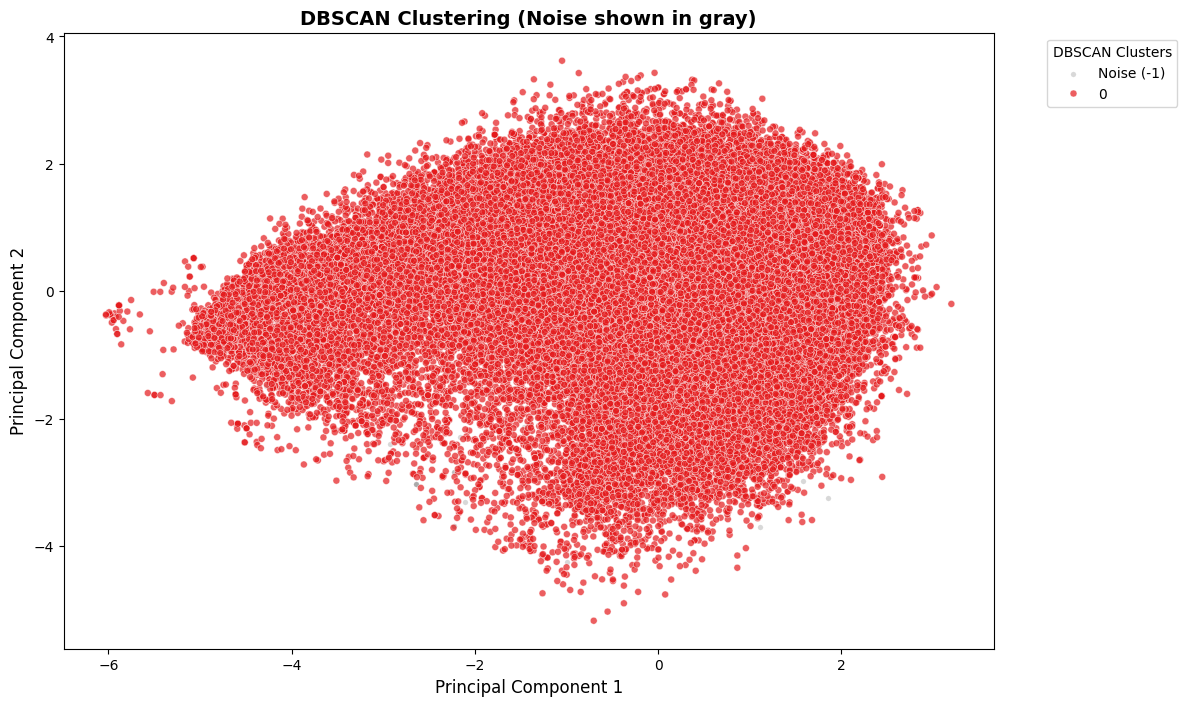

In [27]:
df['dbscan_cluster'] = dbscan_labels

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df[df['dbscan_cluster'] == -1], 
                x='PCA1', y='PCA2', color='gray', alpha=0.3, s=15, label='Noise (-1)')

sns.scatterplot(data=df[df['dbscan_cluster'] != -1], 
                x='PCA1', y='PCA2', hue='dbscan_cluster', 
                palette='Set1', alpha=0.7, s=25)

plt.title('DBSCAN Clustering (Noise shown in gray)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='DBSCAN Clusters')
plt.show()

In [28]:
print(df['dbscan_cluster'].value_counts())

dbscan_cluster
 0    89688
-1       52
Name: count, dtype: int64


In [29]:
df[df['dbscan_cluster'] == -1][['artists', 'track_name', 'track_genre', 
                                  'danceability', 'energy', 'acousticness', 
                                  'speechiness', 'liveness', 'instrumentalness']]

,artists,track_name,track_genre,danceability,energy,acousticness,speechiness,liveness,instrumentalness
7961,J.J. Cale,Call The Doctor,blues,0.4660,0.188000,0.198000,0.0547,0.0820,0.657000
13363,The Kiboomers,Rub a Dub Dub,children,0.7140,0.540000,0.685000,0.5080,0.6610,0.000000
14245,Yusei,We could have been so good together,chill,0.6590,0.353000,0.984000,0.7230,0.3940,0.807000
14317,lofi.samurai;Insowmya,let me hold you,chill,0.5330,0.331000,0.982000,0.5880,0.8290,0.652000
15223,Antonio Vivaldi;Cabin John Middle School Advan...,"Concerto for 2 Cellos in G Minor, RV 531: I. A...",classical,0.4010,0.448000,0.918000,0.5520,0.6820,0.759000
16389,Blackhaine,Black Lights on the M6,club,0.4220,0.687000,0.229000,0.8520,0.0904,0.000078
17342,Ryan Dalton,Weiner Dogs That Breathe Poop,comedy,0.3900,0.607000,0.519000,0.9280,0.0870,0.000000
25951,Turno,DNA,drum-and-bass,0.4800,0.926000,0.000644,0.6790,0.6590,0.561000
26427,InsideInfo;Mefjus;The Upbeats,Footpath,drum-and-bass,0.3270,0.987000,0.000316,0.5360,0.6990,0.777000
30104,XXXTENTACION,Train food,emo,0.4920,0.712000,0.564000,0.6910,0.3570,0.000091
